In [66]:
import numpy as np
import pandas as pd
import sqlite3
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm

In [67]:
conn = sqlite3.connect('database.db')
df = pd.read_sql_query('SELECT * FROM rents', conn)
df.head()

,id,batch_id,timestamp,cnt,t_real,t_feel,hum,wind_speed,weather,is_holiday,is_weekend,season
0,1,1,2015-01-04 00:00:00,182.0,3.0,2.0,93.0,6.0,broken clouds,0.0,1.0,winter
1,2,1,2015-01-04 01:00:00,138.0,NaN,2.5,93.0,5.0,clear,0.0,1.0,winter
2,3,1,2015-01-04 02:00:00,134.0,2.5,2.5,96.5,0.0,clear,0.0,1.0,winter
3,4,1,2015-01-04 03:00:00,72.0,2.0,NaN,100.0,0.0,clear,0.0,1.0,winter
4,5,1,2015-01-04 04:00:00,47.0,2.0,0.0,93.0,6.5,clear,NaN,1.0,winter


In [68]:
df.describe(include='all')

,id,batch_id,timestamp,cnt,t_real,t_feel,hum,wind_speed,weather,is_holiday,is_weekend,season
count,15000.000000,15000.000000,15000,14241.000000,14256.000000,14247.000000,14240.000000,14270.000000,14231,14276.000000,14270.000000,14240
unique,NaN,NaN,15000,NaN,NaN,NaN,NaN,NaN,7,NaN,NaN,4
top,NaN,NaN,2015-01-04 00:00:00,NaN,NaN,NaN,NaN,NaN,clear,NaN,NaN,spring
freq,NaN,NaN,1,NaN,NaN,NaN,NaN,NaN,5058,NaN,NaN,4175
mean,7500.500000,7.832000,NaN,1161.365986,12.909933,11.960097,71.142784,16.307247,NaN,0.020874,0.286195,NaN
std,4330.271354,4.232214,NaN,1096.258189,5.680681,6.727832,14.372096,7.943819,NaN,0.142968,0.451997,NaN
min,1.000000,1.000000,NaN,0.000000,-1.500000,-6.000000,20.500000,0.000000,NaN,0.000000,0.000000,NaN
25%,3750.750000,4.000000,NaN,263.000000,9.000000,6.000000,62.000000,10.000000,NaN,0.000000,0.000000,NaN
50%,7500.500000,8.000000,NaN,855.000000,13.000000,13.000000,73.500000,16.000000,NaN,0.000000,0.000000,NaN
75%,11250.250000,11.000000,NaN,1715.000000,17.000000,17.000000,82.000000,21.000000,NaN,0.000000,1.000000,NaN


In [69]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   id          15000 non-null  int64  
 1   batch_id    15000 non-null  int64  
 2   timestamp   15000 non-null  object 
 3   cnt         14241 non-null  float64
 4   t_real      14256 non-null  float64
 5   t_feel      14247 non-null  float64
 6   hum         14240 non-null  float64
 7   wind_speed  14270 non-null  float64
 8   weather     14231 non-null  object 
 9   is_holiday  14276 non-null  float64
 10  is_weekend  14270 non-null  float64
 11  season      14240 non-null  object 
dtypes: float64(7), int64(2), object(3)
memory usage: 1.4+ MB


In [70]:
numeric_cols = ['t_real', 't_feel', 'hum', 'wind_speed']
categorical_cols = ['is_holiday', 'is_weekend', 'season']

Оценим корреляцию целевой переменной с категориальными признаками:

In [71]:
df['hour'] = pd.to_datetime(df['timestamp']).dt.hour

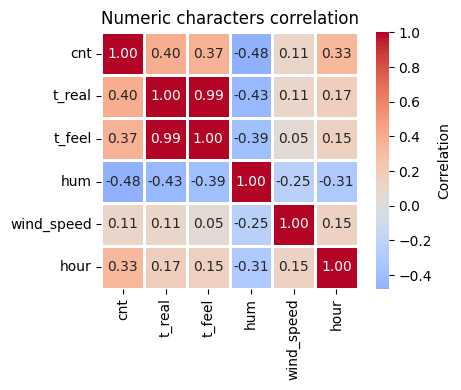

In [72]:
corr_matr = df[['cnt'] + numeric_cols + ['hour']].corr()
plt.figure(figsize=(5,4))
sns.heatmap(corr_matr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True, linewidth=1, cbar_kws={'label':'Correlation'})
plt.title('Numeric characters correlation')
plt.tight_layout()
plt.show()

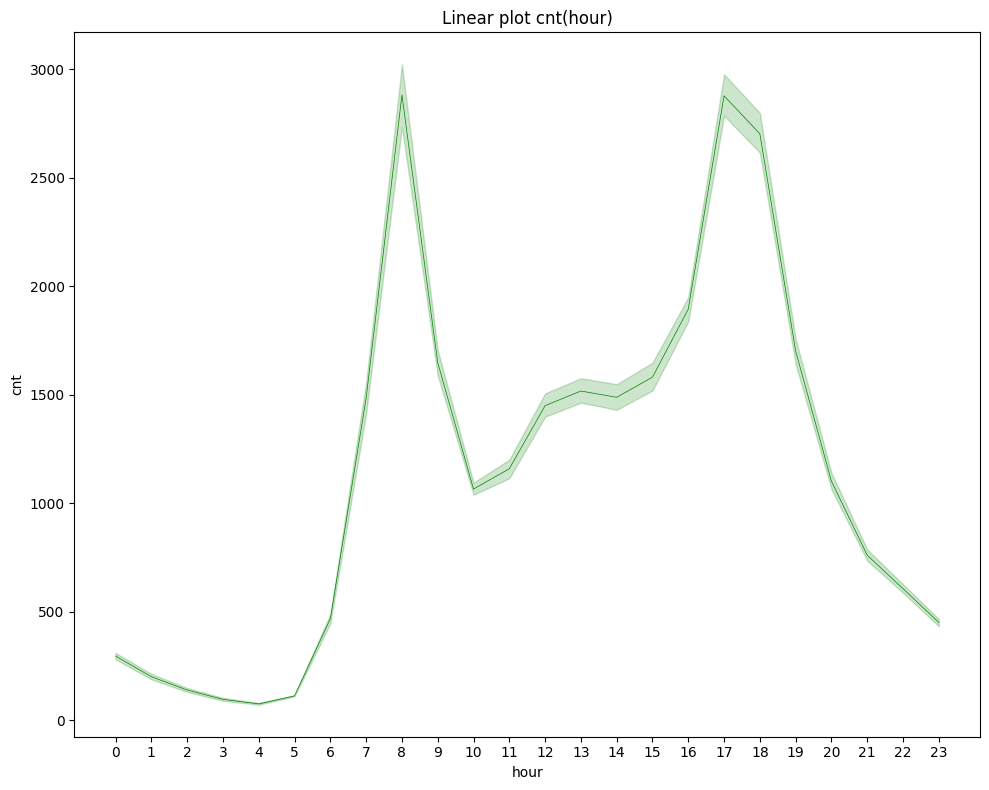

In [73]:
plt.figure(figsize=(10,8))
sns.lineplot(x=df['hour'], y=df['cnt'], color='green', linewidth=0.5)
plt.title('Linear plot cnt(hour)')
plt.xticks(range(0,24))
plt.tight_layout()
plt.show()

Видно, что наибольшим спросом велосипеды польдуются в 8 утра и 18 часов. Это связано, что в это время суток люди едут на работу и возвращаются с нее

In [74]:
df['day_of_week'] = pd.to_datetime(df['timestamp']).dt.day_name()


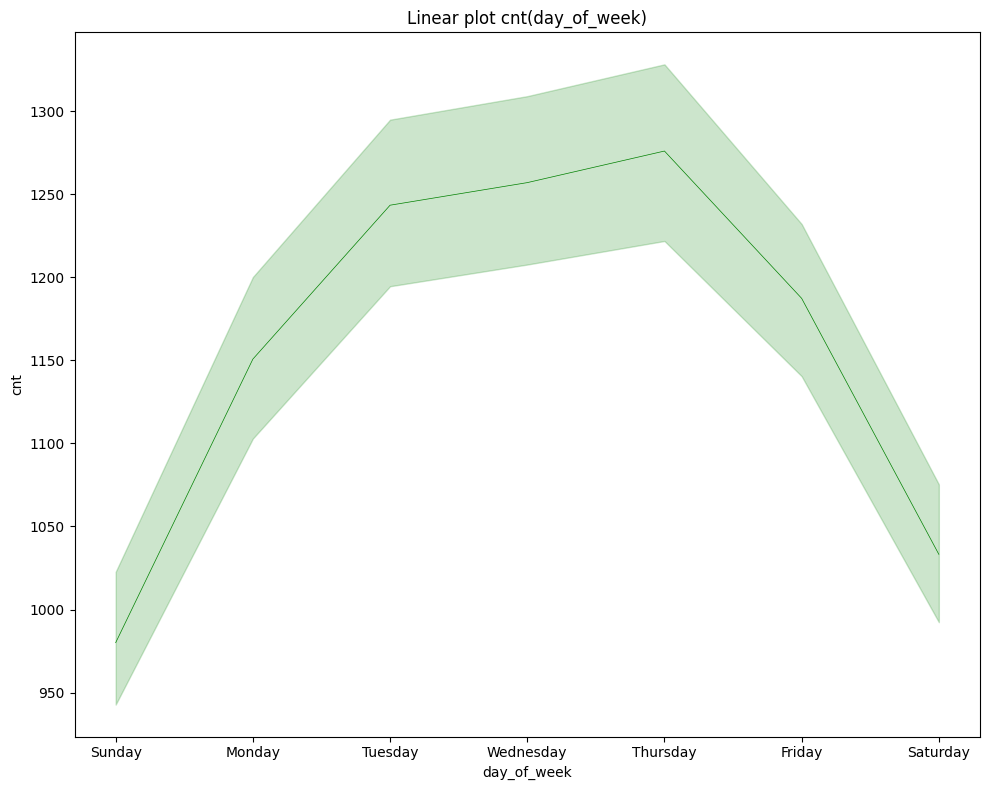

In [75]:
plt.figure(figsize=(10,8))
sns.lineplot(x=df['day_of_week'], y=df['cnt'], color='green', linewidth=0.5)
plt.title('Linear plot cnt(day_of_week)')
# plt.xticks(range(0,24))
plt.tight_layout()
plt.show()

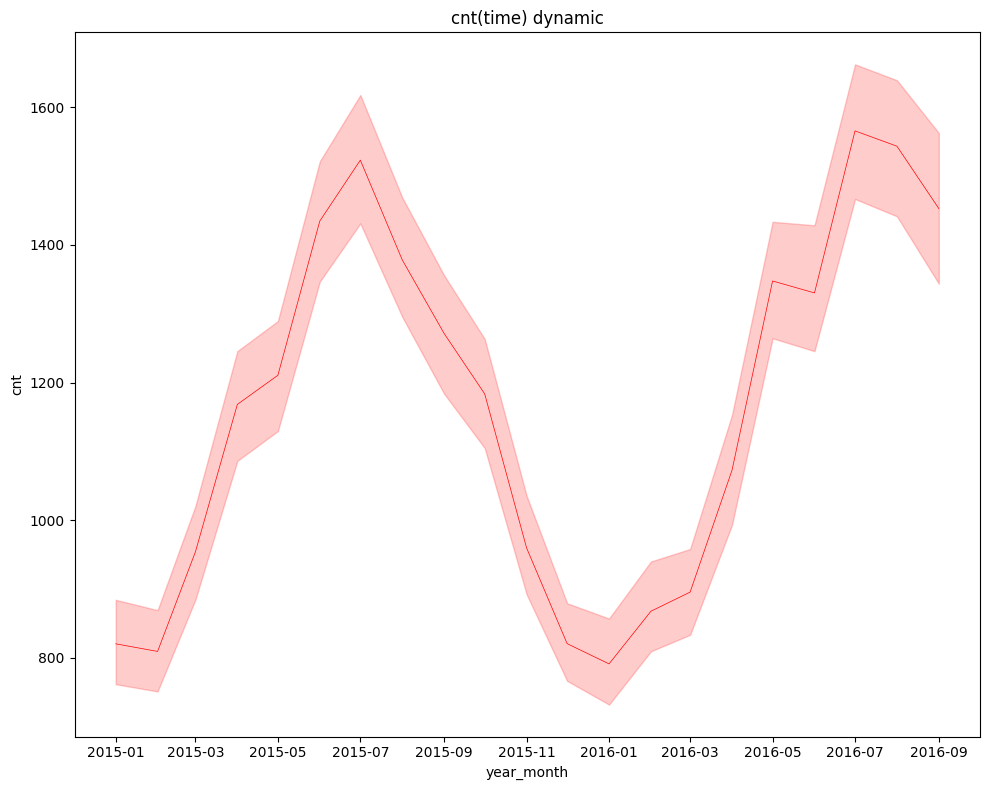

In [76]:
plt.figure(figsize=(10,8))
df['year_month'] = pd.to_datetime(df['timestamp']).dt.to_period('M').dt.start_time
sns.lineplot(x=df['year_month'], y=df['cnt'], color='red', linewidth=0.5)
plt.title('cnt(time) dynamic')
plt.tight_layout()
plt.show()

За оба года июль является наиболее популярным для аренды велосипедов месяцем

Теперь проделаем подобное с is_holiday и is_weekend (ибо они даны в бинарной кодировке):

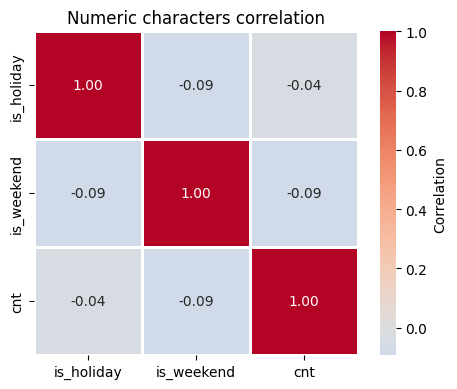

In [77]:
corr_matr = df[['is_holiday', 'is_weekend', 'cnt']].corr()
plt.figure(figsize=(5,4))
sns.heatmap(corr_matr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True, linewidth=1, cbar_kws={'label':'Correlation'})
plt.title('Numeric characters correlation')
plt.tight_layout()
plt.show()

Изучим зависимость целевой перемнной от сезонности:

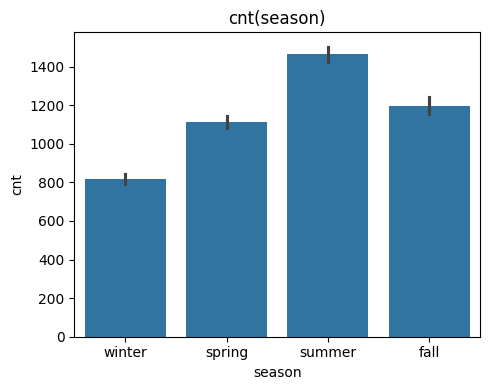

In [78]:
plt.figure(figsize=(5,4))
sns.barplot(x=df['season'], y=df['cnt'])
plt.title('cnt(season)')
plt.tight_layout()
plt.show()

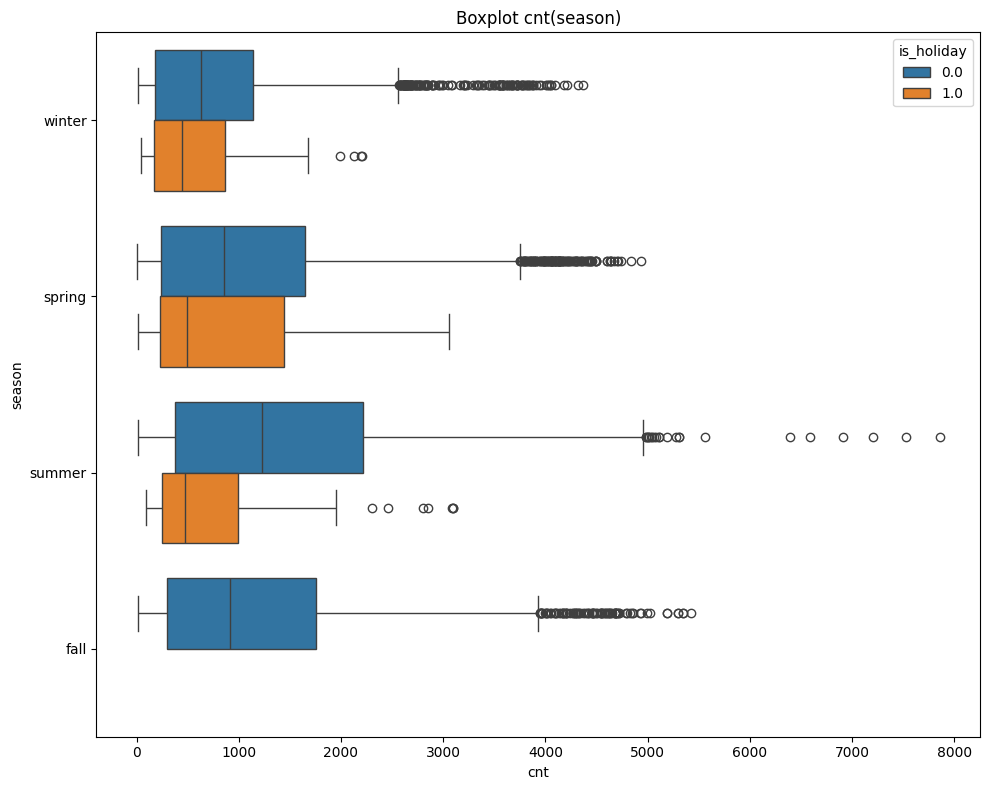

In [79]:
plt.figure(figsize=(10,8))
sns.boxplot(x=df['cnt'], y=df['season'],hue=df['is_holiday'], whis=1.5)
plt.title('Boxplot cnt(season)')
plt.tight_layout()
plt.show()

В выходные люди пользуются прокатом реже, чем в рабочие дни

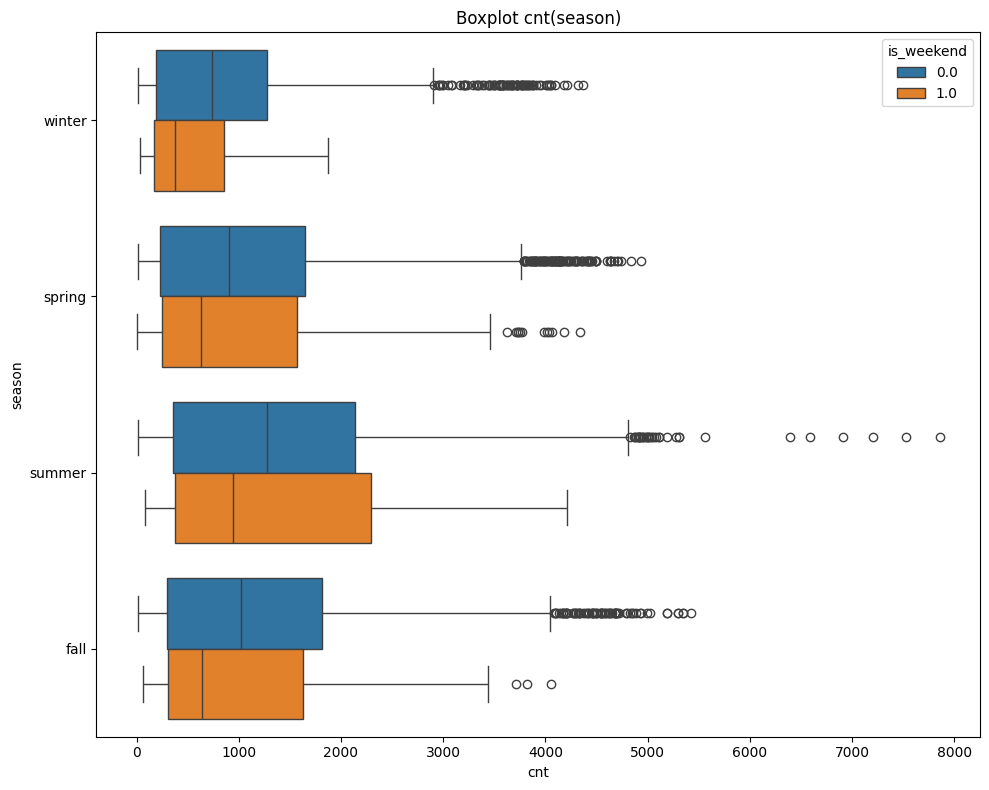

In [80]:
plt.figure(figsize=(10,8))
sns.boxplot(x=df['cnt'], y=df['season'],hue=df['is_weekend'], whis=1.5)
plt.title('Boxplot cnt(season)')
plt.tight_layout()
plt.show()

In [81]:
df[(df['season']=='fall')&(df['is_holiday']==1)]

,id,batch_id,timestamp,cnt,t_real,t_feel,hum,wind_speed,weather,is_holiday,is_weekend,season,hour,day_of_week,year_month


Осенью праздников нет, поэтому аренды в праздники осенью не было

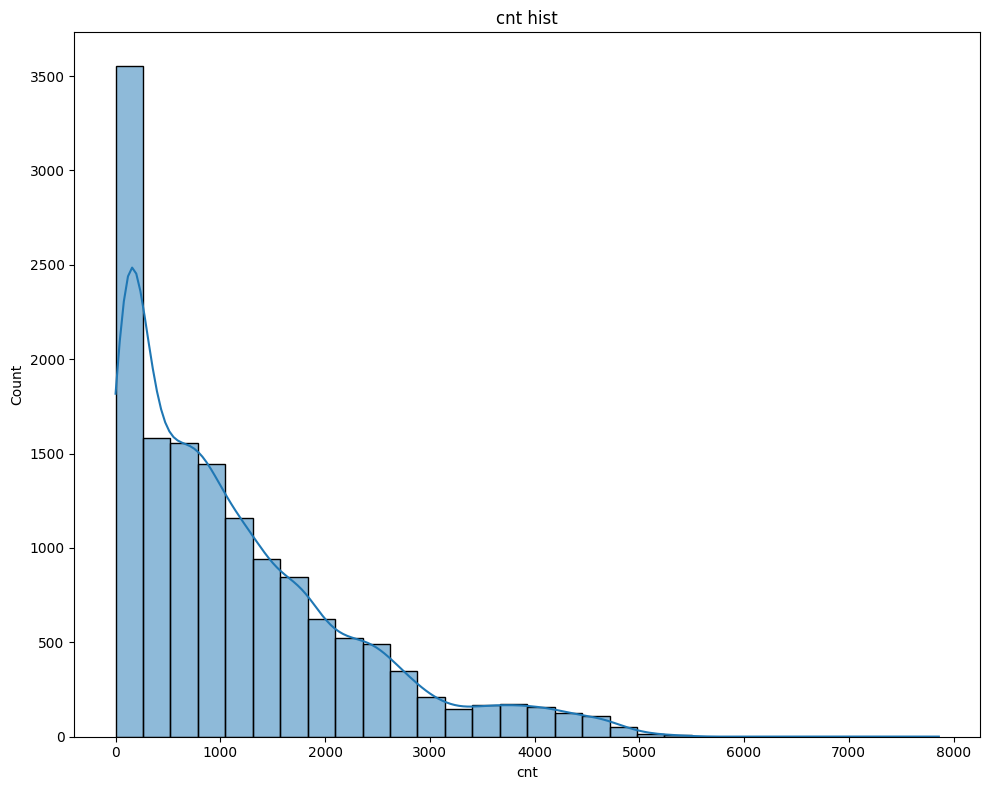

In [82]:
plt.figure(figsize=(10,8))
sns.histplot(x=df['cnt'], kde=True, bins=30)
plt.title('cnt hist')
plt.tight_layout()
plt.show()

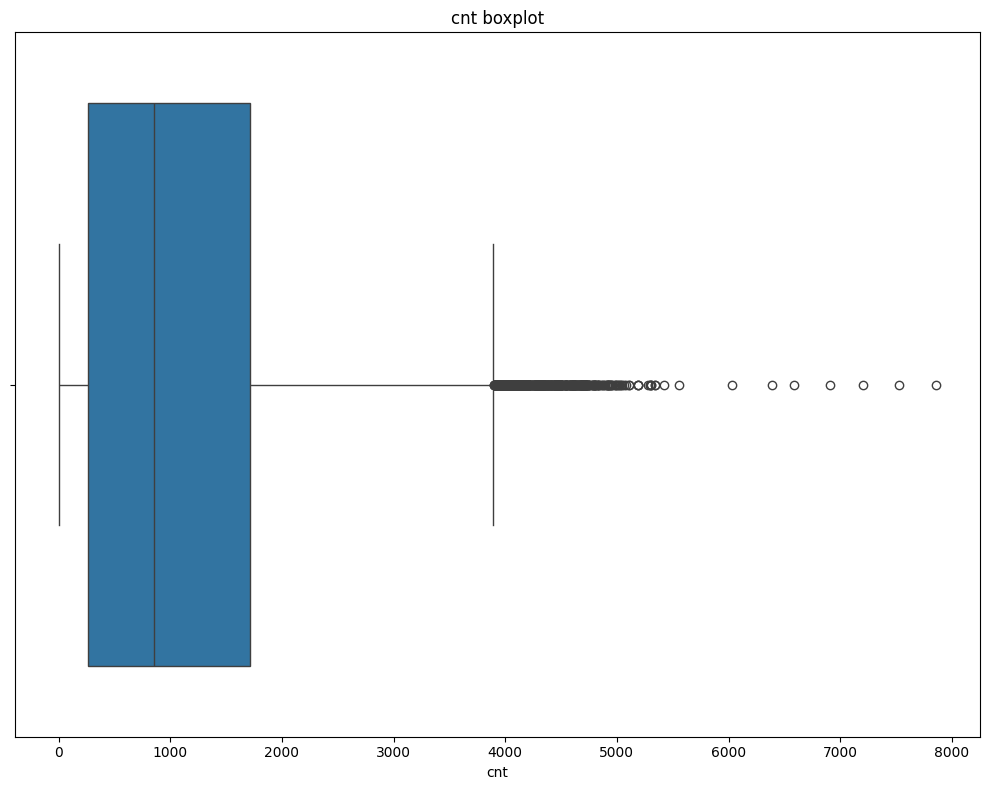

In [83]:
plt.figure(figsize=(10,8))
sns.boxplot(x=df['cnt'], whis=1.5)
plt.title('cnt boxplot')
plt.tight_layout()
plt.show()

In [94]:
from statsmodels.genmod import families
df_ohe = pd.get_dummies(df, columns=['weather'], prefix='weather', drop_first=True, dtype=int)
season_code = {'winter':0, 'spring':1, 'summer':2, 'autumn':3}
df_ohe['season_code'] = df_ohe['season'].map(season_code)
day_week_code = {'Sunday':6, 'Monday':0, 'Tuesday':1, 'Wednesday':2, 'Thursday':3, 'Friday':4, 'Saturday':5}
df_ohe['day_of_week'] = df_ohe['day_of_week'].map(day_week_code)
n_seasons = 4
df_ohe['season_sin'] = np.sin(2*np.pi*df_ohe['season_code']/n_seasons)
df_ohe['season_cos'] = np.cos(2*np.pi*df_ohe['season_code']/n_seasons)
df_ohe['month'] = df_ohe['year_month'].dt.month
df_ohe = df_ohe.dropna() 
df_ohe = df_ohe.drop(['season','season_code'], axis=1)
X = df_ohe.drop(['cnt','id','batch_id', 'timestamp', 'year_month'], axis=1)
y = df_ohe['cnt']
X = sm.add_constant(X)
model = sm.GLM(y, X, family=sm.families.Gaussian(link=sm.families.links.Log()))
res = model.fit()
res.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:                    cnt   No. Observations:                 8142
Model:                            GLM   Df Residuals:                     8124
Model Family:                Gaussian   Df Model:                           17
Link Function:                    Log   Scale:                      7.5867e+05
Method:                          IRLS   Log-Likelihood:                -66663.
Date:                Sat, 04 Apr 2026   Deviance:                   6.1634e+09
Time:                        00:33:00   Pearson chi2:                 6.16e+09
No. Iterations:                    12   Pseudo R-squ. (CS):             0.4258
Covariance Type:            nonrobust                                         
==================================================================================================
                                     coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const                              7.5620      0.085     89.360      0.000       7.396       7.728
t_real                             0.0208      0.010      2.023      0.043       0.001       0.041
t_feel                             0.0154      0.009      1.672      0.094      -0.003       0.033
hum                               -0.0171      0.001    -24.260      0.000      -0.018      -0.016
wind_speed                         0.0021      0.001      2.028      0.043    6.91e-05       0.004
is_holiday                        -0.1016      0.060     -1.683      0.092      -0.220       0.017
is_weekend                        -0.0828      0.027     -3.052      0.002      -0.136      -0.030
hour                               0.0253      0.001     17.265      0.000       0.022       0.028
day_of_week                        0.0070      0.006      1.147      0.251      -0.005       0.019
weather_clear                     -0.1935      0.022     -8.991      0.000      -0.236      -0.151
weather_cloudy                    -0.4896      0.064     -7.677      0.000      -0.615      -0.365
weather_rain                      -0.2617      0.038     -6.823      0.000      -0.337      -0.187
weather_rain with thunderstorm    -0.6539      0.473     -1.382      0.167      -1.581       0.273
weather_scattered clouds           0.0293      0.021      1.420      0.156      -0.011       0.070
weather_snowfall                  -0.9791      0.640     -1.530      0.126      -2.234       0.275
season_sin                         0.0194      0.020      0.961      0.336      -0.020       0.059
season_cos                        -0.0191      0.017     -1.126      0.260      -0.052       0.014
month                             -0.0191      0.005     -3.870      0.000      -0.029      -0.009
==================================================================================================
"""

Сделаем некоторые выводы по построенной модели:
Наиболее статистически значимыми оказались температура, влажность, скорость, ветра, месяц, а также погода, связанная облачностью и наличием дождя, час. Реальная температура статистически более значима температуры по ощущениям. При этом модель показывает логичные для нас явления: чем теплее - чем выше спрос, чем выше влажность - тем хуже. 